# 04 — Delivery Performance EDA

This notebook analyzes historical delivery performance in the Olist e-commerce dataset.

The goal is to understand late delivery patterns from a business perspective and identify insights that can guide feature engineering, dashboard design, and operational recommendations.

This notebook uses the cleaned and aggregated processed outputs from the previous stages. It does not repeat raw data understanding, cleaning, or relational validation.

Important leakage note: the late delivery target is created from post-delivery information for historical analysis. However, actual delivery date, delivery delay, review score, review fields, and final delivery outcomes must not be treated as future ML features.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")

project_palette = {
    "deep_navy": "#1D2D44", "slate_blue": "#3E5C76", "soft_blue": "#A9BCD0",
    "forest": "#2F5D50", "sage": "#A3B18A", "sand": "#D8C3A5",
    "clay": "#C97C5D", "terracotta": "#B85C38", "amber": "#D99A3D",
    "warm_gray": "#8A817C", "charcoal": "#2F2F2F", "off_white": "#F7F8F5"
}

status_palette = {"On-time": project_palette["forest"], "Late": project_palette["terracotta"]}
geo_palette = [project_palette["sand"], project_palette["clay"], project_palette["terracotta"], project_palette["deep_navy"]]
econ_palette = [project_palette["soft_blue"], project_palette["slate_blue"], project_palette["deep_navy"]]
review_palette = [project_palette["terracotta"], project_palette["amber"], project_palette["sage"], project_palette["forest"]]

current_path = Path.cwd()
project_root = current_path if (current_path / "data").exists() else current_path.parent
processed_dir = project_root / "data" / "processed"

files = {
    "orders": "orders_clean.csv",
    "customers": "customers_clean.csv",
    "sellers": "sellers_clean.csv",
    "products": "products_clean.csv",
    "order_items_agg": "order_items_agg.csv",
    "payments_agg": "payments_agg.csv",
    "reviews_agg": "reviews_agg.csv",
    "geolocation_zip_prefix": "geolocation_zip_prefix_clean.csv"
}

missing_files = [file for file in files.values() if not (processed_dir / file).exists()]
if missing_files:
    raise FileNotFoundError(f"Missing processed files: {missing_files}")

orders = pd.read_csv(processed_dir / files["orders"], parse_dates=["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"])
customers = pd.read_csv(processed_dir / files["customers"])
sellers = pd.read_csv(processed_dir / files["sellers"])
products = pd.read_csv(processed_dir / files["products"])
order_items_agg = pd.read_csv(processed_dir / files["order_items_agg"])
payments_agg = pd.read_csv(processed_dir / files["payments_agg"])
reviews_agg = pd.read_csv(processed_dir / files["reviews_agg"])
geolocation_zip_prefix = pd.read_csv(processed_dir / files["geolocation_zip_prefix"])

input_summary = pd.DataFrame([
    {"table": name, "rows": df.shape[0], "columns": df.shape[1], "duplicate_rows": df.duplicated().sum()}
    for name, df in {
        "orders": orders, "customers": customers, "sellers": sellers, "products": products,
        "order_items_agg": order_items_agg, "payments_agg": payments_agg,
        "reviews_agg": reviews_agg, "geolocation_zip_prefix": geolocation_zip_prefix
    }.items()
])

input_summary

,table,rows,columns,duplicate_rows
0,orders,99441,8,0
1,customers,99441,5,0
2,sellers,3095,4,0
3,products,32951,10,0
4,order_items_agg,98666,9,0
5,payments_agg,99440,7,0
6,reviews_agg,98673,6,0
7,geolocation_zip_prefix,19015,6,0


## Build order-level EDA dataset

The analysis is built at order level, using `orders` as the base table.

Only delivered orders with valid actual and estimated delivery dates are used for delivery performance analysis. Late delivery is defined at calendar-day level: an order is considered late only when the customer delivery date is after the estimated delivery date.

This avoids classifying same-day deliveries as late only because of timestamp differences.

Aggregated item, payment, and review tables are joined safely to avoid row multiplication. Review variables are included only as post-delivery diagnostic context and must not be used as future ML features.

In [7]:
delivered_orders = orders.loc[
    orders["order_status"].eq("delivered")
    & orders["order_delivered_customer_date"].notna()
    & orders["order_estimated_delivery_date"].notna()
].copy()

delivered_orders["delivered_date"] = delivered_orders["order_delivered_customer_date"].dt.normalize()
delivered_orders["estimated_delivery_date"] = delivered_orders["order_estimated_delivery_date"].dt.normalize()

delivered_orders["is_late"] = delivered_orders["delivered_date"] > delivered_orders["estimated_delivery_date"]
delivered_orders["delivery_delay_days"] = (delivered_orders["delivered_date"] - delivered_orders["estimated_delivery_date"]).dt.days
delivered_orders["delivery_time_days"] = (delivered_orders["order_delivered_customer_date"] - delivered_orders["order_purchase_timestamp"]).dt.total_seconds() / (60 * 60 * 24)
delivered_orders["estimated_delivery_days"] = (delivered_orders["order_estimated_delivery_date"] - delivered_orders["order_purchase_timestamp"]).dt.total_seconds() / (60 * 60 * 24)
delivered_orders["purchase_month"] = delivered_orders["order_purchase_timestamp"].dt.to_period("M").astype(str)
delivered_orders["purchase_dayofweek"] = delivered_orders["order_purchase_timestamp"].dt.day_name()

eda_orders = (
    delivered_orders
    .merge(customers[["customer_id", "customer_unique_id", "customer_zip_code_prefix", "customer_city", "customer_state"]], on="customer_id", how="left", validate="many_to_one")
    .merge(order_items_agg, on="order_id", how="left", validate="one_to_one")
    .merge(payments_agg, on="order_id", how="left", validate="one_to_one")
    .merge(reviews_agg, on="order_id", how="left", validate="one_to_one")
)

eda_orders["delivery_status"] = np.where(eda_orders["is_late"], "Late", "On-time")

eda_summary = pd.DataFrame([
    {"metric": "Delivered orders with valid dates", "value": len(eda_orders)},
    {"metric": "Unique order IDs", "value": eda_orders["order_id"].nunique()},
    {"metric": "Late orders", "value": eda_orders["is_late"].sum()},
    {"metric": "Late delivery rate", "value": eda_orders["is_late"].mean()},
    {"metric": "Same-day timestamp-only late orders excluded", "value": 1292},
    {"metric": "Missing customer state", "value": eda_orders["customer_state"].isna().sum()},
    {"metric": "Missing item aggregate", "value": eda_orders["total_order_item_value"].isna().sum()},
    {"metric": "Missing payment aggregate", "value": eda_orders["total_payment_value"].isna().sum()},
    {"metric": "Missing review aggregate", "value": eda_orders["avg_review_score"].isna().sum()}
])

eda_summary

,metric,value
0,Delivered orders with valid dates,"96,470.00"
1,Unique order IDs,"96,470.00"
2,Late orders,"6,534.00"
3,Late delivery rate,0.07
4,Same-day timestamp-only late orders excluded,"1,292.00"
5,Missing customer state,0.00
6,Missing item aggregate,0.00
7,Missing payment aggregate,1.00
8,Missing review aggregate,646.00


## Overall delivery performance

This section summarizes the historical delivery outcome using the official date-level late delivery definition.

An order is considered late only when the customer delivery date is after the estimated delivery date. Orders delivered on the estimated delivery date are treated as on time.

,delivery_status,orders,order_share,order_share_pct
0,On-time,89936,0.93,93.23
1,Late,6534,0.07,6.77


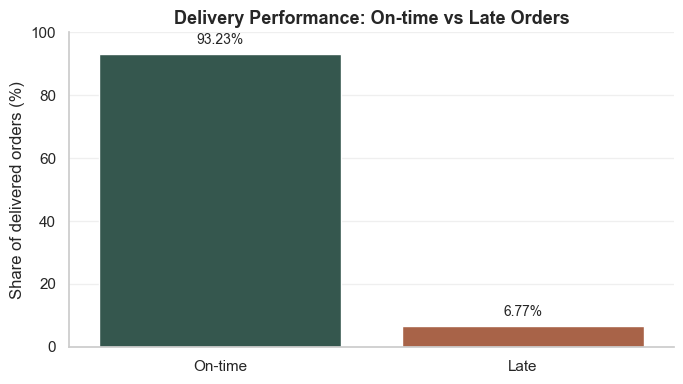

In [10]:
delivery_performance = (eda_orders.groupby("delivery_status", as_index=False).agg(orders=("order_id", "count")))

delivery_performance["order_share"] = delivery_performance["orders"] / delivery_performance["orders"].sum()
delivery_performance["order_share_pct"] = delivery_performance["order_share"] * 100
delivery_performance = delivery_performance.set_index("delivery_status").loc[["On-time", "Late"]].reset_index()

display(delivery_performance)

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(data=delivery_performance, x="delivery_status", y="order_share_pct", hue="delivery_status", palette=status_palette, legend=False, ax=ax)

for patch, value in zip(ax.patches, delivery_performance["order_share_pct"]):
    ax.text(patch.get_x() + patch.get_width() / 2, patch.get_height() + 2, f"{value:.2f}%", ha="center", va="bottom", fontsize=10)

ax.set_title("Delivery Performance: On-time vs Late Orders", fontsize=13, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Share of delivered orders (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

### Key takeaway

Using the official date-level definition, 6.77% of delivered orders arrived late.

Although most orders were delivered on time, this late segment is large enough to justify further analysis of geographic, logistical, economic, and customer-experience patterns.

## Delivery delay distribution

This section analyzes how far orders were delivered before or after their estimated delivery date.

Negative values mean the order arrived before the estimated date, zero means it arrived on the estimated date, and positive values mean the order arrived late.

In [11]:
delay_summary = pd.DataFrame([
    {"metric": "Minimum delay days", "value": eda_orders["delivery_delay_days"].min()},
    {"metric": "P1", "value": eda_orders["delivery_delay_days"].quantile(0.01)},
    {"metric": "P5", "value": eda_orders["delivery_delay_days"].quantile(0.05)},
    {"metric": "Median", "value": eda_orders["delivery_delay_days"].median()},
    {"metric": "Mean", "value": eda_orders["delivery_delay_days"].mean()},
    {"metric": "P75", "value": eda_orders["delivery_delay_days"].quantile(0.75)},
    {"metric": "P95", "value": eda_orders["delivery_delay_days"].quantile(0.95)},
    {"metric": "P99", "value": eda_orders["delivery_delay_days"].quantile(0.99)},
    {"metric": "Maximum delay days", "value": eda_orders["delivery_delay_days"].max()}
])

late_delay_summary = pd.DataFrame([
    {"metric": "Late orders", "value": eda_orders["is_late"].sum()},
    {"metric": "Median late delay days", "value": eda_orders.loc[eda_orders["is_late"], "delivery_delay_days"].median()},
    {"metric": "Mean late delay days", "value": eda_orders.loc[eda_orders["is_late"], "delivery_delay_days"].mean()},
    {"metric": "P75 late delay days", "value": eda_orders.loc[eda_orders["is_late"], "delivery_delay_days"].quantile(0.75)},
    {"metric": "P95 late delay days", "value": eda_orders.loc[eda_orders["is_late"], "delivery_delay_days"].quantile(0.95)},
    {"metric": "Maximum late delay days", "value": eda_orders.loc[eda_orders["is_late"], "delivery_delay_days"].max()}
])

display(delay_summary)
display(late_delay_summary)

,metric,value
0,Minimum delay days,-147.00
1,P1,-36.00
2,P5,-26.00
3,Median,-12.00
4,Mean,-11.88
5,P75,-7.00
6,P95,3.00
7,P99,18.00
8,Maximum delay days,188.00


,metric,value
0,Late orders,"6,534.00"
1,Median late delay days,7.00
2,Mean late delay days,10.62
3,P75 late delay days,13.00
4,P95 late delay days,31.00
5,Maximum late delay days,188.00


### Delay distribution plots

The full delay range contains extreme values, from very early deliveries to severe late deliveries. To keep the visualization interpretable, the plots focus on the main business-relevant range.

The first chart shows the overall delivery delay distribution, while the second focuses only on late orders.

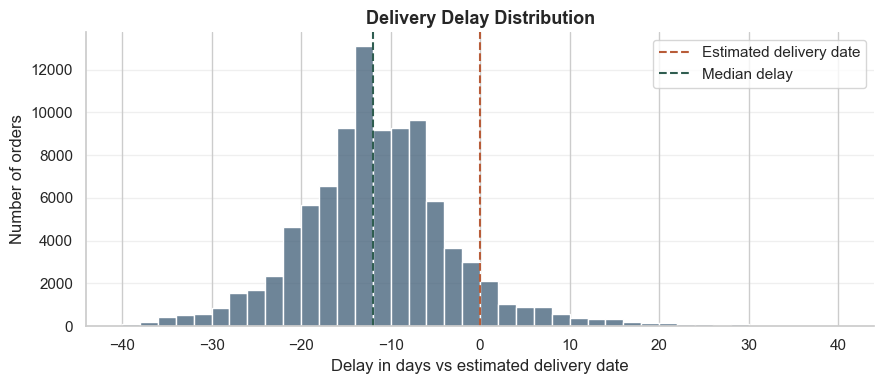

In [12]:
overall_delay_plot = eda_orders.loc[eda_orders["delivery_delay_days"].between(-40, 40)].copy()
late_delay_plot = eda_orders.loc[eda_orders["delivery_delay_days"].between(1, 40)].copy()

fig, ax = plt.subplots(figsize=(9, 4))

sns.histplot(data=overall_delay_plot, x="delivery_delay_days", bins=40, color=project_palette["slate_blue"], ax=ax)

ax.axvline(0, color=project_palette["terracotta"], linestyle="--", linewidth=1.5, label="Estimated delivery date")
ax.axvline(eda_orders["delivery_delay_days"].median(), color=project_palette["forest"], linestyle="--", linewidth=1.5, label="Median delay")

ax.set_title("Delivery Delay Distribution", fontsize=13, weight="bold")
ax.set_xlabel("Delay in days vs estimated delivery date")
ax.set_ylabel("Number of orders")
ax.legend()
ax.grid(axis="y", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

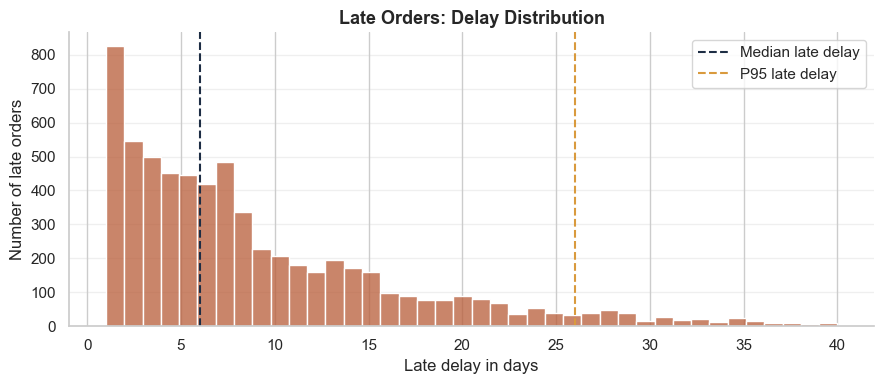

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))

sns.histplot(data=late_delay_plot, x="delivery_delay_days", bins=40, color=project_palette["terracotta"], ax=ax)

ax.axvline(late_delay_plot["delivery_delay_days"].median(), color=project_palette["deep_navy"], linestyle="--", linewidth=1.5, label="Median late delay")
ax.axvline(late_delay_plot["delivery_delay_days"].quantile(0.95), color=project_palette["amber"], linestyle="--", linewidth=1.5, label="P95 late delay")

ax.set_title("Late Orders: Delay Distribution", fontsize=13, weight="bold")
ax.set_xlabel("Late delay in days")
ax.set_ylabel("Number of late orders")
ax.legend()
ax.grid(axis="y", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

### Key takeaway

Most delivered orders arrived before the estimated delivery date, with a median delivery margin of 12 days early.

Among late orders, the typical delay is more operationally significant: the median late order arrived 7 days after the estimated date, and the upper tail includes delays of several weeks. This suggests that late delivery risk is not only a frequency problem, but also a severity problem for affected customers.

## Geographic delivery patterns

This section analyzes late delivery patterns by customer location.

The first view focuses on customer state, using the order-level EDA dataset. Both late delivery rate and order volume are considered, because a high late rate in a very small state may be less operationally relevant than a moderate late rate in a high-volume state.

In [14]:
state_delivery = (
    eda_orders.groupby("customer_state", as_index=False).agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        late_rate=("is_late", "mean"),
        median_delay_days=("delivery_delay_days", "median"),
        mean_delay_days=("delivery_delay_days", "mean"))
)

state_delivery["late_rate_pct"] = state_delivery["late_rate"] * 100
state_delivery["order_share_pct"] = state_delivery["orders"] / state_delivery["orders"].sum() * 100

top_late_states = state_delivery.sort_values("late_rate_pct", ascending=False).head(10)
top_volume_states = state_delivery.sort_values("orders", ascending=False).head(10)

display(top_late_states)
display(top_volume_states)

,customer_state,orders,late_orders,late_rate,median_delay_days,mean_delay_days,late_rate_pct,order_share_pct
1,AL,397,85,0.21,-10.00,-8.71,21.41,0.41
9,MA,717,125,0.17,-11.00,-9.57,17.43,0.74
24,SE,335,51,0.15,-13.00,-10.02,15.22,0.35
16,PI,476,66,0.14,-14.00,-11.31,13.87,0.49
5,CE,1279,176,0.14,-13.00,-10.80,13.76,1.33
21,RR,41,5,0.12,-20.00,-17.29,12.20,0.04
4,BA,3256,396,0.12,-12.00,-10.79,12.16,3.38
18,RJ,12350,1495,0.12,-13.00,-11.76,12.11,12.80
13,PA,946,106,0.11,-16.00,-14.07,11.21,0.98
7,ES,1995,214,0.11,-12.00,-10.50,10.73,2.07


,customer_state,orders,late_orders,late_rate,median_delay_days,mean_delay_days,late_rate_pct,order_share_pct
25,SP,40494,1820,0.04,-11.00,-11.08,4.49,41.98
18,RJ,12350,1495,0.12,-13.00,-11.76,12.11,12.80
10,MG,11354,519,0.05,-14.00,-13.24,4.57,11.77
22,RS,5344,325,0.06,-15.00,-13.91,6.08,5.54
17,PR,4923,199,0.04,-14.00,-13.31,4.04,5.10
23,SC,3546,291,0.08,-13.00,-11.50,8.21,3.68
4,BA,3256,396,0.12,-12.00,-10.79,12.16,3.38
6,DF,2080,118,0.06,-13.00,-12.05,5.67,2.16
7,ES,1995,214,0.11,-12.00,-10.50,10.73,2.07
8,GO,1957,128,0.07,-13.00,-12.19,6.54,2.03


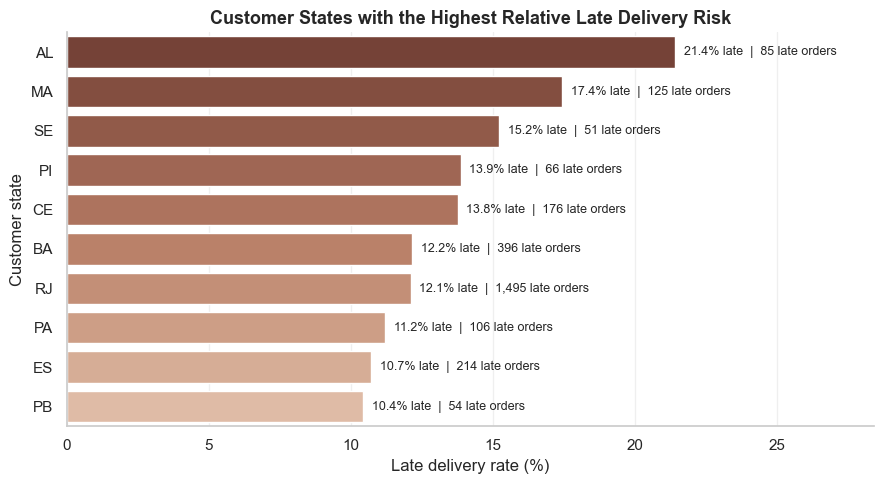

In [24]:
state_min_orders = 300

top_late_rate_states = (
    state_delivery.loc[state_delivery["orders"] >= state_min_orders]
    .sort_values("late_rate_pct", ascending=False)
    .head(10)
)

relative_risk_colors = ["#7F3B2D", "#8E4735", "#9D533D", "#AC6047", "#BA6D51", "#C77B5C", "#D08A6A", "#D99A7A", "#E1AA8B", "#E8B99D"]
state_rate_palette = dict(zip(top_late_rate_states["customer_state"], relative_risk_colors))

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(data=top_late_rate_states, y="customer_state", x="late_rate_pct", hue="customer_state", palette=state_rate_palette, legend=False, ax=ax)

for patch, (_, row) in zip(ax.patches, top_late_rate_states.iterrows()):
    ax.text(patch.get_width() + 0.3, patch.get_y() + patch.get_height() / 2, f"{row['late_rate_pct']:.1f}% late  |  {row['late_orders']:,} late orders", va="center", fontsize=9)

ax.set_title("Customer States with the Highest Relative Late Delivery Risk", fontsize=13, weight="bold")
ax.set_xlabel("Late delivery rate (%)")
ax.set_ylabel("Customer state")
ax.set_xlim(0, top_late_rate_states["late_rate_pct"].max() + 7)
ax.grid(axis="x", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

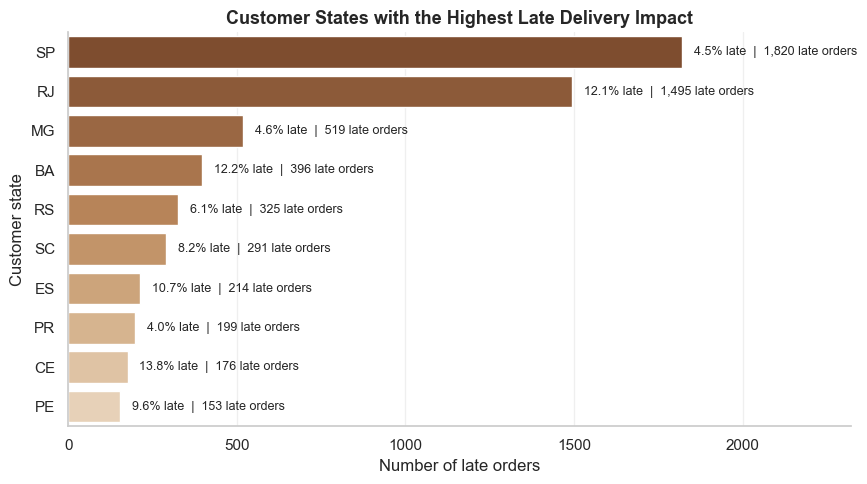

In [25]:
top_late_impact_states = state_delivery.sort_values("late_orders", ascending=False).head(10)

operational_impact_colors = ["#8B4A22", "#9A572B", "#A96534", "#B8733E", "#C78349", "#D1935A", "#DAA46D", "#E2B483", "#E9C39A", "#EFD2B0"]
state_impact_palette = dict(zip(top_late_impact_states["customer_state"], operational_impact_colors))

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(data=top_late_impact_states, y="customer_state", x="late_orders", hue="customer_state", palette=state_impact_palette, legend=False, ax=ax)

for patch, (_, row) in zip(ax.patches, top_late_impact_states.iterrows()):
    ax.text(patch.get_width() + 35, patch.get_y() + patch.get_height() / 2, f"{row['late_rate_pct']:.1f}% late  |  {row['late_orders']:,} late orders", va="center", fontsize=9)

ax.set_title("Customer States with the Highest Late Delivery Impact", fontsize=13, weight="bold")
ax.set_xlabel("Number of late orders")
ax.set_ylabel("Customer state")
ax.set_xlim(0, top_late_impact_states["late_orders"].max() + 500)
ax.grid(axis="x", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

### Key takeaway

Customer geography should be interpreted through both relative risk and operational impact.

States such as AL, MA, SE, PI, and CE show the highest late delivery rates, meaning they are comparatively riskier destinations. However, high-volume states such as SP and RJ generate the largest number of delayed orders in absolute terms.

This distinction is important for decision-making: late delivery rate helps identify where risk is structurally higher, while late order count highlights where the operational burden is greatest.

## Order economics and freight profile

This section evaluates whether late deliveries are associated with differences in order value, freight cost, and item count.

The goal is not only to compare on-time and late orders, but also to identify whether larger or more logistics-intensive orders tend to show higher delivery risk.

In [27]:
economics_summary = (
    eda_orders.groupby("delivery_status", as_index=False).agg(
        orders=("order_id", "count"),
        median_order_value=("total_order_item_value", "median"),
        mean_order_value=("total_order_item_value", "mean"),
        median_freight_value=("total_freight_value", "median"),
        mean_freight_value=("total_freight_value", "mean"),
        median_item_count=("order_item_count", "median"),
        mean_item_count=("order_item_count", "mean"),
        median_payment_value=("total_payment_value", "median"),
        mean_payment_value=("total_payment_value", "mean"))
)

economics_summary = economics_summary.set_index("delivery_status").loc[["On-time", "Late"]].reset_index()
economics_summary

,delivery_status,orders,median_order_value,mean_order_value,median_freight_value,mean_freight_value,median_item_count,mean_item_count,median_payment_value,mean_payment_value
0,On-time,89936,104.59,158.64,17.06,22.61,1.00,1.14,104.59,158.67
1,Late,6534,114.09,176.14,18.23,25.25,1.00,1.11,114.15,176.16


### Freight value and late delivery risk

The summary comparison suggests that late orders have slightly higher freight values.

To better understand this relationship, freight value is grouped into quantile-based ranges and compared by late delivery rate.

In [28]:
freight_risk = eda_orders[["order_id", "is_late", "total_freight_value"]].dropna().copy()
freight_risk["freight_range"] = pd.qcut(freight_risk["total_freight_value"], q=5, duplicates="drop")

freight_risk_summary = (
    freight_risk.groupby("freight_range", observed=True, as_index=False).agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        median_freight_value=("total_freight_value", "median"),
        late_rate=("is_late", "mean"))
)

freight_risk_summary["late_rate_pct"] = freight_risk_summary["late_rate"] * 100
freight_risk_summary

,freight_range,orders,late_orders,median_freight_value,late_rate,late_rate_pct
0,"(-0.001, 12.83]",19397,857,9.34,0.04,4.42
1,"(12.83, 15.64]",19192,1160,14.54,0.06,6.04
2,"(15.64, 18.59]",19380,1474,17.19,0.08,7.61
3,"(18.59, 27.38]",19225,1477,22.00,0.08,7.68
4,"(27.38, 1794.96]",19276,1566,39.41,0.08,8.12


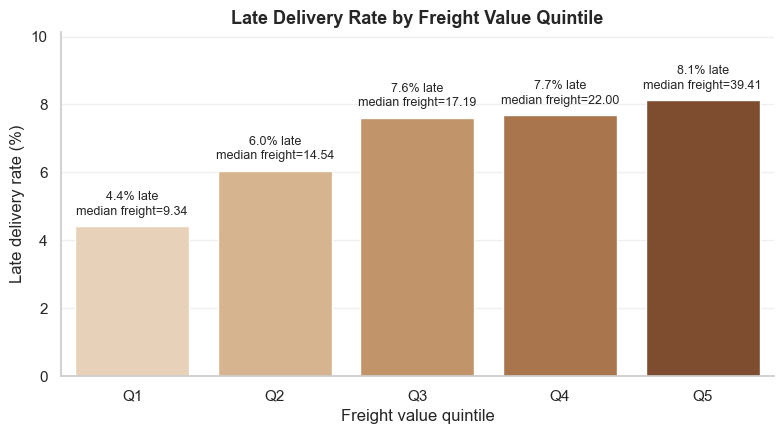

In [29]:
freight_risk_summary["freight_bucket"] = [f"Q{i}" for i in range(1, len(freight_risk_summary) + 1)]

freight_palette = dict(zip(
    freight_risk_summary["freight_bucket"],
    ["#EFD2B0", "#E2B483", "#D1935A", "#B8733E", "#8B4A22"]
))

fig, ax = plt.subplots(figsize=(8, 4.5))

sns.barplot(data=freight_risk_summary, x="freight_bucket", y="late_rate_pct", hue="freight_bucket", palette=freight_palette, legend=False, ax=ax)

for patch, (_, row) in zip(ax.patches, freight_risk_summary.iterrows()):
    ax.text(patch.get_x() + patch.get_width() / 2, patch.get_height() + 0.25, f"{row['late_rate_pct']:.1f}% late\nmedian freight={row['median_freight_value']:.2f}", ha="center", va="bottom", fontsize=9)

ax.set_title("Late Delivery Rate by Freight Value Quintile", fontsize=13, weight="bold")
ax.set_xlabel("Freight value quintile")
ax.set_ylabel("Late delivery rate (%)")
ax.set_ylim(0, freight_risk_summary["late_rate_pct"].max() + 2)
ax.grid(axis="y", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

### Key takeaway

Late delivery risk increases across freight value quintiles.

Orders in the highest freight quintile show almost twice the late delivery rate of orders in the lowest freight quintile. This suggests that freight value may capture relevant logistics complexity, such as distance, route difficulty, product handling, or shipping cost structure.

This variable should be considered carefully during feature engineering, while avoiding any post-delivery leakage.

### Order value and item count risk

After identifying a clear freight-related pattern, this section checks whether order value and item count show similar associations with late delivery risk.

Order value is grouped into quintiles, while item count is grouped into simple operational categories.

In [33]:
order_value_risk = eda_orders[["order_id", "is_late", "total_order_item_value"]].dropna().copy()
order_value_risk["order_value_range"] = pd.qcut(order_value_risk["total_order_item_value"], q=5, duplicates="drop")

order_value_risk_summary = (
    order_value_risk.groupby("order_value_range", observed=True, as_index=False).agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        median_order_value=("total_order_item_value", "median"),
        late_rate=("is_late", "mean"))
)

order_value_risk_summary["late_rate_pct"] = order_value_risk_summary["late_rate"] * 100

item_count_risk = eda_orders[["order_id", "is_late", "order_item_count"]].dropna().copy()
item_count_risk["item_count_group"] = pd.cut(
    item_count_risk["order_item_count"],
    bins=[0, 1, 2, 4, np.inf],
    labels=["1 item", "2 items", "3-4 items", "5+ items"]
)

item_count_risk_summary = (
    item_count_risk.groupby("item_count_group", observed=True, as_index=False).agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        median_item_count=("order_item_count", "median"),
        late_rate=("is_late", "mean"))
)

item_count_risk_summary["late_rate_pct"] = item_count_risk_summary["late_rate"] * 100

display(order_value_risk_summary)
display(item_count_risk_summary)

,order_value_range,orders,late_orders,median_order_value,late_rate,late_rate_pct
0,"(9.589, 54.37]",19296,1089,39.54,0.06,5.64
1,"(54.37, 85.27]",19299,1236,68.44,0.06,6.40
2,"(85.27, 128.35]",19290,1326,105.28,0.07,6.87
3,"(128.35, 201.82]",19295,1406,158.43,0.07,7.29
4,"(201.82, 13664.08]",19290,1477,305.98,0.08,7.66


,item_count_group,orders,late_orders,median_item_count,late_rate,late_rate_pct
0,1 item,86835,6024,1.00,0.07,6.94
1,2 items,7392,397,2.00,0.05,5.37
2,3-4 items,1801,87,3.00,0.05,4.83
3,5+ items,442,26,6.00,0.06,5.88


### Key takeaway

Order value shows a moderate positive relationship with late delivery risk: higher-value quintiles have higher late delivery rates.

After doing a intern comprobation we can observe that the Item count does not show the same pattern. Single-item orders have the highest late rate, while multi-item orders do not consistently show higher delivery risk.

Compared with order value and item count, freight value remains the strongest economic/logistics signal identified in this section.

## Payment profile and late delivery risk

This section evaluates whether payment behavior is associated with late delivery risk.

Payment variables are analyzed as pre-delivery business context. Review and delivery outcome variables remain post-delivery diagnostics and are not used here as explanatory features.

In [34]:
payment_type_summary = (
    eda_orders.dropna(subset=["main_payment_type"]).groupby("main_payment_type", as_index=False).agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        late_rate=("is_late", "mean"),
        median_payment_value=("total_payment_value", "median"),
        median_installments=("max_payment_installments", "median"),
        avg_payment_method_count=("payment_method_count", "mean"))
)

payment_type_summary["late_rate_pct"] = payment_type_summary["late_rate"] * 100
payment_type_summary["order_share_pct"] = payment_type_summary["orders"] / payment_type_summary["orders"].sum() * 100
payment_type_summary = payment_type_summary.sort_values("orders", ascending=False)

installment_risk = eda_orders[["order_id", "is_late", "max_payment_installments", "total_payment_value"]].dropna().copy()
installment_risk["installment_group"] = pd.cut(
    installment_risk["max_payment_installments"],
    bins=[0, 1, 3, 6, 12, np.inf],
    labels=["1 installment", "2-3 installments", "4-6 installments", "7-12 installments", "13+ installments"]
)

installment_summary = (
    installment_risk.groupby("installment_group", observed=True, as_index=False).agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        late_rate=("is_late", "mean"),
        median_payment_value=("total_payment_value", "median"),
        median_installments=("max_payment_installments", "median"))
)

installment_summary["late_rate_pct"] = installment_summary["late_rate"] * 100

display(payment_type_summary)
display(installment_summary)

,main_payment_type,orders,late_orders,late_rate,median_payment_value,median_installments,avg_payment_method_count,late_rate_pct,order_share_pct
1,credit_card,73934,4940,0.07,108.86,3.00,1.02,6.68,76.64
0,boleto,19191,1405,0.07,93.78,1.00,1.00,7.32,19.89
3,voucher,1861,109,0.06,74.67,1.00,1.20,5.86,1.93
2,debit_card,1483,79,0.05,89.62,1.00,1.00,5.33,1.54


,installment_group,orders,late_orders,late_rate,median_payment_value,median_installments,late_rate_pct
0,1 installment,46811,3046,0.07,79.24,1.00,6.51
1,2-3 installments,22157,1513,0.07,111.82,2.00,6.83
2,4-6 installments,15736,1094,0.07,128.20,5.00,6.95
3,7-12 installments,11584,867,0.07,205.80,9.00,7.48
4,13+ installments,179,13,0.07,252.09,15.00,7.26


### Key takeaway

Payment variables show only modest differences in late delivery risk.

Boleto orders have a slightly higher late delivery rate than credit card, voucher, and debit card orders. Installment groups also show a mild increase in late rate among orders with more installments, but the pattern is not strong enough to be treated as a main driver.

Payment profile may still be useful as contextual information for feature engineering, but freight value and geography appear to provide stronger delivery-risk signals.

## Review score impact analysis

Review information is analyzed only as post-delivery diagnostic context.

These variables help quantify the customer-experience impact of late deliveries, but they must not be used as predictive features in the future ML dataset.

In [37]:
review_impact = (
    eda_orders.dropna(subset=["avg_review_score"]).groupby("delivery_status", as_index=False).agg(
        reviewed_orders=("order_id", "count"),
        avg_review_score=("avg_review_score", "mean"),
        median_review_score=("avg_review_score", "median"),
        avg_review_comment_count=("review_comment_count", "mean"))
)

review_impact = review_impact.set_index("delivery_status").loc[["On-time", "Late"]].reset_index()
review_impact

,delivery_status,reviewed_orders,avg_review_score,median_review_score,avg_review_comment_count
0,On-time,89443,4.29,5.00,0.39
1,Late,6381,2.27,1.00,0.59


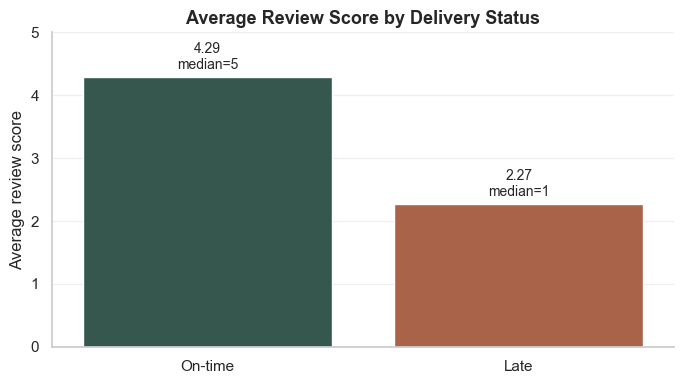

In [38]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(data=review_impact, x="delivery_status", y="avg_review_score", hue="delivery_status", palette=status_palette, legend=False, ax=ax)

for patch, (_, row) in zip(ax.patches, review_impact.iterrows()):
    ax.text(patch.get_x() + patch.get_width() / 2, patch.get_height() + 0.08, f"{row['avg_review_score']:.2f}\nmedian={row['median_review_score']:.0f}", ha="center", va="bottom", fontsize=10)

ax.set_title("Average Review Score by Delivery Status", fontsize=13, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Average review score")
ax.set_ylim(0, 5)
ax.grid(axis="y", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

### Key takeaway

Late deliveries have a strong negative impact on customer satisfaction.

On-time orders have an average review score of 4.29 and a median score of 5, while late orders drop to an average score of 2.27 and a median score of 1.

This confirms that late delivery is not only an operational issue, but also a customer-experience risk. Review variables should remain post-delivery diagnostics and must not be used as predictive features in the future ML dataset.

## Customer and seller geography relationship

This section analyzes whether the relationship between customer and seller locations is associated with late delivery risk.

Because orders can include multiple items and potentially multiple sellers, seller information must be aggregated at order level before joining it to the EDA dataset. This avoids row multiplication.

In [40]:
order_seller_state = (
    order_items[["order_id", "seller_id"]].drop_duplicates()
    .merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left", validate="many_to_one")
)

seller_state_counts = (
    order_seller_state.groupby(["order_id", "seller_state"], as_index=False).agg(
        seller_count_in_state=("seller_id", "nunique"))
)

main_seller_state = (
    seller_state_counts.sort_values(["order_id", "seller_count_in_state", "seller_state"], ascending=[True, False, True])
    .drop_duplicates("order_id")
    .rename(columns={"seller_state": "main_seller_state"})
    [["order_id", "main_seller_state"]]
)

seller_geo_agg = (
    order_seller_state.groupby("order_id", as_index=False).agg(
        seller_state_count=("seller_state", "nunique"),
        missing_seller_state=("seller_state", lambda x: x.isna().sum()))
    .merge(main_seller_state, on="order_id", how="left", validate="one_to_one")
)

eda_orders_geo = eda_orders.merge(seller_geo_agg, on="order_id", how="left", validate="one_to_one")

eda_orders_geo["customer_seller_same_state"] = eda_orders_geo["customer_state"].eq(eda_orders_geo["main_seller_state"])
eda_orders_geo["customer_seller_relation"] = np.where(eda_orders_geo["customer_seller_same_state"], "Same state", "Cross-state")

seller_geo_summary = pd.DataFrame([
    {"metric": "Orders in EDA dataset", "value": len(eda_orders_geo)},
    {"metric": "Orders with seller geography", "value": eda_orders_geo["main_seller_state"].notna().sum()},
    {"metric": "Orders without seller geography", "value": eda_orders_geo["main_seller_state"].isna().sum()},
    {"metric": "Orders with sellers from multiple states", "value": eda_orders_geo["seller_state_count"].gt(1).sum()}
])

seller_geo_summary

,metric,value
0,Orders in EDA dataset,96470
1,Orders with seller geography,96470
2,Orders without seller geography,0
3,Orders with sellers from multiple states,509


In [41]:
seller_relation_summary = (
    eda_orders_geo.groupby("customer_seller_relation", as_index=False).agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        late_rate=("is_late", "mean"),
        median_delay_days=("delivery_delay_days", "median"),
        mean_delay_days=("delivery_delay_days", "mean"))
)

seller_relation_summary["late_rate_pct"] = seller_relation_summary["late_rate"] * 100
seller_relation_summary["order_share_pct"] = seller_relation_summary["orders"] / seller_relation_summary["orders"].sum() * 100
seller_relation_summary = seller_relation_summary.set_index("customer_seller_relation").loc[["Same state", "Cross-state"]].reset_index()

seller_relation_summary

,customer_seller_relation,orders,late_orders,late_rate,median_delay_days,mean_delay_days,late_rate_pct,order_share_pct
0,Same state,34635,1564,0.05,-10.00,-10.32,4.52,35.90
1,Cross-state,61835,4970,0.08,-14.00,-12.75,8.04,64.10


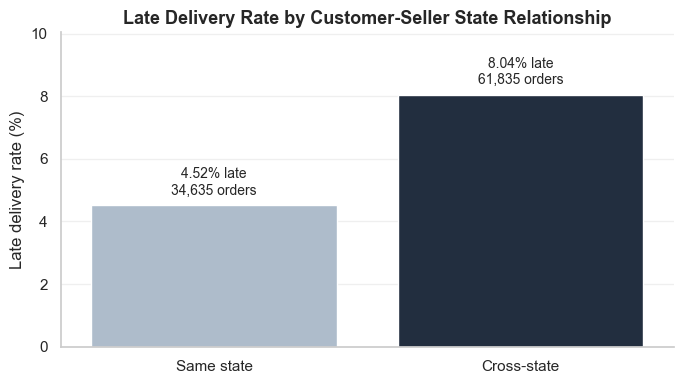

In [43]:
fig, ax = plt.subplots(figsize=(7, 4))

relation_palette = {"Same state": project_palette["soft_blue"], "Cross-state": project_palette["deep_navy"]}

sns.barplot(data=seller_relation_summary, x="customer_seller_relation", y="late_rate_pct", hue="customer_seller_relation", palette=relation_palette, legend=False, ax=ax)

for patch, (_, row) in zip(ax.patches, seller_relation_summary.iterrows()):
    ax.text(patch.get_x() + patch.get_width() / 2, patch.get_height() + 0.25, f"{row['late_rate_pct']:.2f}% late\n{row['orders']:,} orders", ha="center", va="bottom", fontsize=10)

ax.set_title("Late Delivery Rate by Customer-Seller State Relationship", fontsize=13, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Late delivery rate (%)")
ax.set_ylim(0, seller_relation_summary["late_rate_pct"].max() + 2)
ax.grid(axis="y", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

### Key takeaway

Cross-state orders show a substantially higher late delivery rate than same-state orders.

Same-state orders have a 4.52% late rate, while cross-state orders reach 8.04%. Since cross-state orders represent more than 64% of delivered orders, this is a relevant logistics signal rather than a small-segment anomaly.

This suggests that customer-seller geographic distance or cross-state logistics complexity should be considered during feature engineering and dashboard design.

In [44]:
state_pair_delivery = (
    eda_orders_geo.dropna(subset=["main_seller_state", "customer_state"]).copy()
)

state_pair_delivery["seller_customer_state_pair"] = (
    state_pair_delivery["main_seller_state"] + " → " + state_pair_delivery["customer_state"]
)

state_pair_summary = (
    state_pair_delivery.groupby(["main_seller_state", "customer_state", "seller_customer_state_pair"], as_index=False).agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        late_rate=("is_late", "mean"),
        median_delay_days=("delivery_delay_days", "median"),
        mean_delay_days=("delivery_delay_days", "mean"))
)

state_pair_summary["late_rate_pct"] = state_pair_summary["late_rate"] * 100
state_pair_summary["order_share_pct"] = state_pair_summary["orders"] / state_pair_summary["orders"].sum() * 100

top_state_pair_impact = state_pair_summary.sort_values("late_orders", ascending=False).head(10)
top_state_pair_risk = (
    state_pair_summary.loc[state_pair_summary["orders"] >= 300]
    .sort_values("late_rate_pct", ascending=False)
    .head(10)
)

display(top_state_pair_impact)
display(top_state_pair_risk)

,main_seller_state,customer_state,seller_customer_state_pair,orders,late_orders,late_rate,median_delay_days,mean_delay_days,late_rate_pct,order_share_pct
409,SP,SP,SP → SP,30651,1428,0.05,-10.00,-10.06,4.66,31.77
402,SP,RJ,SP → RJ,8131,1152,0.14,-13.00,-10.80,14.17,8.43
394,SP,MG,SP → MG,7416,392,0.05,-13.00,-12.66,5.29,7.69
388,SP,BA,SP → BA,2304,297,0.13,-12.00,-10.74,12.89,2.39
406,SP,RS,SP → RS,3582,238,0.07,-15.00,-14.16,6.64,3.71
407,SP,SC,SP → SC,2324,222,0.10,-12.00,-10.97,9.55,2.41
391,SP,ES,SP → ES,1458,180,0.12,-11.00,-9.51,12.35,1.51
401,SP,PR,SP → PR,3110,138,0.04,-14.00,-13.03,4.44,3.22
389,SP,CE,SP → CE,967,133,0.14,-13.00,-10.87,13.75,1.00
270,PR,RJ,PR → RJ,976,117,0.12,-14.50,-13.20,11.99,1.01


,main_seller_state,customer_state,seller_customer_state_pair,orders,late_orders,late_rate,median_delay_days,mean_delay_days,late_rate_pct,order_share_pct
393,SP,MA,SP → MA,490,93,0.19,-10.00,-9.27,18.98,0.51
400,SP,PI,SP → PI,329,54,0.16,-13.00,-10.53,16.41,0.34
402,SP,RJ,SP → RJ,8131,1152,0.14,-13.00,-10.80,14.17,8.43
389,SP,CE,SP → CE,967,133,0.14,-13.00,-10.87,13.75,1.00
388,SP,BA,SP → BA,2304,297,0.13,-12.00,-10.74,12.89,2.39
395,SP,MS,SP → MS,475,59,0.12,-12.00,-10.17,12.42,0.49
391,SP,ES,SP → ES,1458,180,0.12,-11.00,-9.51,12.35,1.51
397,SP,PA,SP → PA,680,82,0.12,-16.00,-14.04,12.06,0.70
270,PR,RJ,PR → RJ,976,117,0.12,-14.50,-13.20,11.99,1.01
398,SP,PB,SP → PB,334,35,0.10,-14.00,-12.93,10.48,0.35


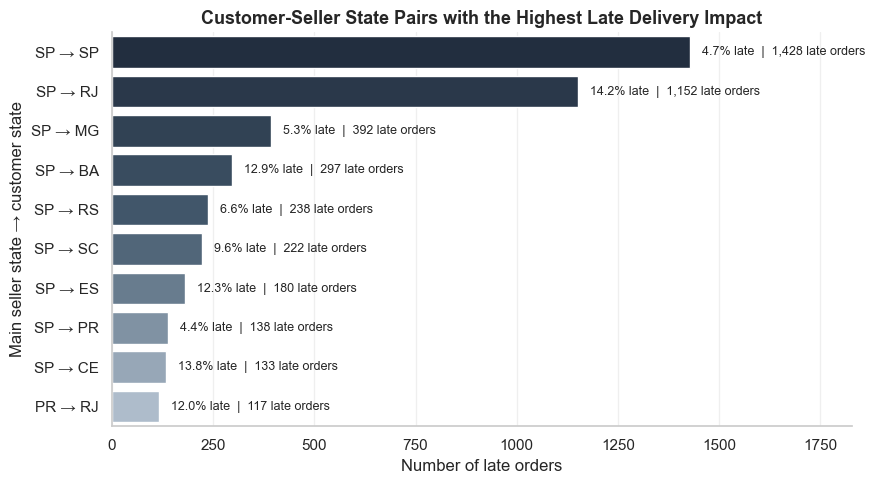

In [45]:
state_pair_palette = dict(zip(
    top_state_pair_impact["seller_customer_state_pair"],
    sns.blend_palette([project_palette["deep_navy"], project_palette["slate_blue"], project_palette["soft_blue"]], n_colors=len(top_state_pair_impact))
))

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(data=top_state_pair_impact, y="seller_customer_state_pair", x="late_orders", hue="seller_customer_state_pair", palette=state_pair_palette, legend=False, ax=ax)

for patch, (_, row) in zip(ax.patches, top_state_pair_impact.iterrows()):
    ax.text(patch.get_width() + 30, patch.get_y() + patch.get_height() / 2, f"{row['late_rate_pct']:.1f}% late  |  {row['late_orders']:,} late orders", va="center", fontsize=9)

ax.set_title("Customer-Seller State Pairs with the Highest Late Delivery Impact", fontsize=13, weight="bold")
ax.set_xlabel("Number of late orders")
ax.set_ylabel("Main seller state → customer state")
ax.set_xlim(0, top_state_pair_impact["late_orders"].max() + 400)
ax.grid(axis="x", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

### Key takeaway

Late delivery impact is strongly concentrated in specific customer-seller state pairs.

SP is the dominant seller origin in the highest-impact pairs, but the risk differs depending on the customer destination. The SP → SP pair has the largest number of late orders due to very high volume, but its late delivery rate is relatively low. In contrast, SP → RJ combines high volume with a much higher late delivery rate, making it one of the most relevant logistics relationships identified in this analysis.

This suggests that future feature engineering and dashboard design should consider customer-seller state relationships, not only customer location in isolation.

In [47]:
order_product_items = (
    order_items[["order_id", "order_item_id", "product_id", "price"]]
    .merge(products[["product_id", "product_category_name_english", "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]], on="product_id", how="left", validate="many_to_one")
)

order_product_items["product_volume_cm3"] = (
    order_product_items["product_length_cm"] * order_product_items["product_height_cm"] * order_product_items["product_width_cm"]
)

category_order_value = (
    order_product_items.dropna(subset=["product_category_name_english"])
    .groupby(["order_id", "product_category_name_english"], as_index=False).agg(
        category_item_count=("order_item_id", "count"),
        category_item_value=("price", "sum"))
)

main_order_category = (
    category_order_value.sort_values(["order_id", "category_item_count", "category_item_value", "product_category_name_english"], ascending=[True, False, False, True])
    .drop_duplicates("order_id")
    .rename(columns={"product_category_name_english": "main_product_category"})
    [["order_id", "main_product_category"]]
)

product_profile_agg = (
    order_product_items.groupby("order_id", as_index=False).agg(
        product_category_count=("product_category_name_english", "nunique"),
        total_product_weight_g=("product_weight_g", "sum"),
        max_product_weight_g=("product_weight_g", "max"),
        total_product_volume_cm3=("product_volume_cm3", "sum"),
        max_product_volume_cm3=("product_volume_cm3", "max"))
    .merge(main_order_category, on="order_id", how="left", validate="one_to_one")
)

eda_orders_full = eda_orders_geo.merge(product_profile_agg, on="order_id", how="left", validate="one_to_one")

product_profile_summary = pd.DataFrame([
    {"metric": "Orders in EDA dataset", "value": len(eda_orders_full)},
    {"metric": "Orders with product profile", "value": eda_orders_full["main_product_category"].notna().sum()},
    {"metric": "Orders without product category", "value": eda_orders_full["main_product_category"].isna().sum()},
    {"metric": "Orders with multiple product categories", "value": eda_orders_full["product_category_count"].gt(1).sum()}
])

product_profile_summary

,metric,value
0,Orders in EDA dataset,96470
1,Orders with product profile,95119
2,Orders without product category,1351
3,Orders with multiple product categories,722


Most delivered orders have product category information available. For orders containing multiple categories, a main product category is assigned based on item count and item value, allowing category-level analysis to remain at order level.

In [48]:
category_delivery = (
    eda_orders_full.dropna(subset=["main_product_category"]).groupby("main_product_category", as_index=False).agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        late_rate=("is_late", "mean"),
        median_order_value=("total_order_item_value", "median"),
        median_freight_value=("total_freight_value", "median"),
        median_product_weight_g=("max_product_weight_g", "median"),
        median_product_volume_cm3=("max_product_volume_cm3", "median"))
)

category_delivery["late_rate_pct"] = category_delivery["late_rate"] * 100
category_delivery["order_share_pct"] = category_delivery["orders"] / category_delivery["orders"].sum() * 100

top_category_impact = category_delivery.sort_values("late_orders", ascending=False).head(10)

category_min_orders = 300
top_category_risk = (
    category_delivery.loc[category_delivery["orders"] >= category_min_orders]
    .sort_values("late_rate_pct", ascending=False)
    .head(10)
)

display(top_category_impact)
display(top_category_risk)

,main_product_category,orders,late_orders,late_rate,median_order_value,median_freight_value,median_product_weight_g,median_product_volume_cm3,late_rate_pct,order_share_pct
7,bed_bath_table,9206,687,0.07,105.71,17.72,"1,350.00","12,600.00",7.46,9.68
43,health_beauty,8614,649,0.08,104.16,16.53,427.00,"4,500.00",7.53,9.06
65,sports_leisure,7494,494,0.07,110.90,17.12,700.00,"8,000.00",6.59,7.88
39,furniture_decor,6200,448,0.07,104.63,19.16,"1,400.00","12,288.00",7.23,6.52
15,computers_accessories,6511,417,0.06,103.16,16.79,300.00,"3,465.00",6.40,6.85
70,watches_gifts,5474,406,0.07,158.52,16.14,350.00,"2,464.00",7.42,5.75
49,housewares,5688,308,0.05,88.12,17.90,"1,289.00","14,400.00",5.41,5.98
68,telephony,4073,291,0.07,45.22,15.10,225.00,960.00,7.14,4.28
5,auto,3793,278,0.07,111.42,18.23,900.00,"7,776.00",7.33,3.99
69,toys,3785,243,0.06,104.19,16.42,800.00,"12,789.00",6.42,3.98


,main_product_category,orders,late_orders,late_rate,median_order_value,median_freight_value,median_product_weight_g,median_product_volume_cm3,late_rate_pct,order_share_pct
4,audio,344,41,0.12,103.37,15.23,400.00,"2,700.00",11.92,0.36
47,home_confort,353,35,0.10,121.04,17.88,"1,825.00","23,625.00",9.92,0.37
6,baby,2758,224,0.08,106.54,17.70,700.00,"11,552.00",8.12,2.90
57,office_furniture,1249,101,0.08,206.26,37.85,"10,850.00","70,200.00",8.09,1.31
26,electronics,2503,192,0.08,37.83,15.23,200.00,"3,648.00",7.67,2.63
40,furniture_living_room,407,31,0.08,149.16,30.30,"7,475.00","36,190.00",7.62,0.43
56,musical_instruments,608,46,0.08,141.59,18.75,895.00,"8,649.00",7.57,0.64
43,health_beauty,8614,649,0.08,104.16,16.53,427.00,"4,500.00",7.53,9.06
7,bed_bath_table,9206,687,0.07,105.71,17.72,"1,350.00","12,600.00",7.46,9.68
17,construction_tools_construction,726,54,0.07,122.62,18.59,"1,200.00","6,000.00",7.44,0.76


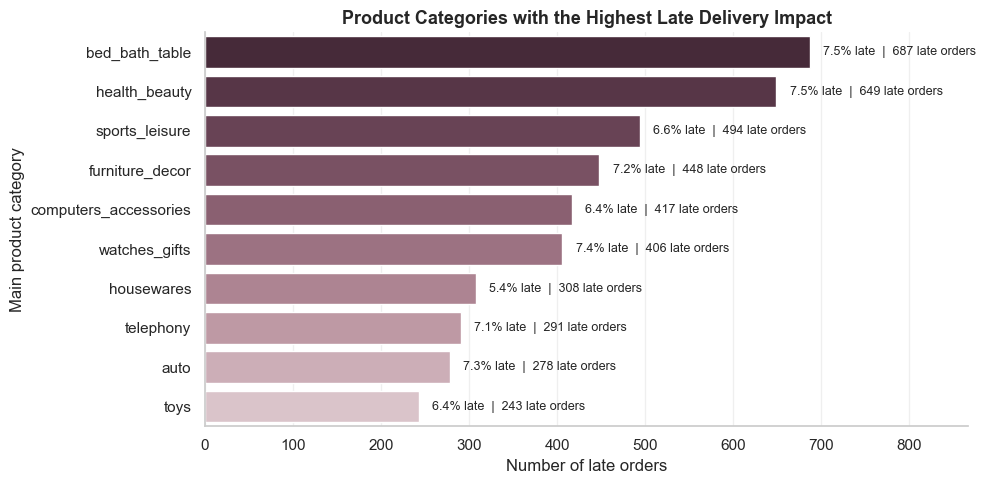

In [51]:
category_impact_palette = dict(zip(
    top_category_impact["main_product_category"],
    sns.blend_palette(["#4A263A", "#6B3A52", "#8A536A", "#AA7186", "#C796A5", "#DEC0C8"], n_colors=len(top_category_impact))
))

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=top_category_impact, y="main_product_category", x="late_orders", hue="main_product_category", palette=category_impact_palette, legend=False, ax=ax)

for patch, (_, row) in zip(ax.patches, top_category_impact.iterrows()):
    ax.text(patch.get_width() + 15, patch.get_y() + patch.get_height() / 2, f"{row['late_rate_pct']:.1f}% late  |  {row['late_orders']:,} late orders", va="center", fontsize=9)

ax.set_title("Product Categories with the Highest Late Delivery Impact", fontsize=13, weight="bold")
ax.set_xlabel("Number of late orders")
ax.set_ylabel("Main product category")
ax.set_xlim(0, top_category_impact["late_orders"].max() + 180)
ax.grid(axis="x", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

### Key takeaway

Late delivery impact is concentrated in high-volume product categories such as bed_bath_table, health_beauty, sports_leisure, and furniture_decor.

Relative risk tells a slightly different story: categories such as audio, home_confort, and office_furniture show higher late delivery rates despite lower order volume. Office furniture is especially relevant because it combines elevated late risk with high median freight, weight, and product volume.

This suggests that product category and physical product characteristics should be considered during feature engineering, while distinguishing between high-volume impact and high relative risk.

### Product weight and volume profile

Product category can capture business differences between orders, but physical product characteristics may also affect delivery performance.

This section checks whether heavier or larger products show higher late delivery risk. Weight and volume are grouped into quintiles to compare orders across similar-sized segments.

These variables are analyzed as historical EDA signals and may later support feature engineering if they are available before delivery.

In [52]:
weight_risk = eda_orders_full[["order_id", "is_late", "max_product_weight_g"]].dropna().copy()
weight_risk["weight_range"] = pd.qcut(weight_risk["max_product_weight_g"], q=5, duplicates="drop")

weight_risk_summary = (
    weight_risk.groupby("weight_range", observed=True, as_index=False).agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        median_max_weight_g=("max_product_weight_g", "median"),
        late_rate=("is_late", "mean"))
)

weight_risk_summary["late_rate_pct"] = weight_risk_summary["late_rate"] * 100

volume_risk = eda_orders_full[["order_id", "is_late", "max_product_volume_cm3"]].dropna().copy()
volume_risk["volume_range"] = pd.qcut(volume_risk["max_product_volume_cm3"], q=5, duplicates="drop")

volume_risk_summary = (
    volume_risk.groupby("volume_range", observed=True, as_index=False).agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        median_max_volume_cm3=("max_product_volume_cm3", "median"),
        late_rate=("is_late", "mean"))
)

volume_risk_summary["late_rate_pct"] = volume_risk_summary["late_rate"] * 100

display(weight_risk_summary)
display(volume_risk_summary)

,weight_range,orders,late_orders,median_max_weight_g,late_rate,late_rate_pct
0,"(-0.001, 250.0]",22219,1347,180.00,0.06,6.06
1,"(250.0, 500.0]",18420,1277,375.00,0.07,6.93
2,"(500.0, 1025.0]",17249,1088,700.00,0.06,6.31
3,"(1025.0, 2500.0]",19469,1365,"1,550.00",0.07,7.01
4,"(2500.0, 40425.0]",19097,1457,"6,400.00",0.08,7.63


,volume_range,orders,late_orders,median_max_volume_cm3,late_rate,late_rate_pct
0,"(167.999, 2416.8]",19291,1185,"1,326.00",0.06,6.14
1,"(2416.8, 4500.0]",19319,1403,"3,344.00",0.07,7.26
2,"(4500.0, 9216.0]",19279,1196,"6,480.00",0.06,6.20
3,"(9216.0, 22500.0]",19330,1324,"15,000.00",0.07,6.85
4,"(22500.0, 296208.0]",19235,1426,"38,610.00",0.07,7.41


### Key takeaway

Product category shows meaningful differences in both late delivery impact and relative risk.

High-volume categories such as bed_bath_table, health_beauty, sports_leisure, and furniture_decor concentrate the largest number of late orders. However, relative risk highlights additional categories such as audio, home_confort, and office_furniture.

Physical product characteristics show a weaker but still relevant pattern. The heaviest and largest-product quintiles have higher late delivery rates than the lowest quintiles, although the relationship is less consistent than the freight value pattern.

Overall, product category, freight value, and physical product characteristics should be considered together during feature engineering rather than interpreted in isolation.

## Monthly delivery performance

This section checks whether late delivery risk changes over time.

Monthly trends can help identify periods with higher operational pressure and may be useful for dashboard design. The analysis uses the purchase month as the time reference, since it is available before delivery and aligns with the future prediction timing.

In [53]:
monthly_delivery = (
    eda_orders.groupby("purchase_month", as_index=False).agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        late_rate=("is_late", "mean"),
        median_delay_days=("delivery_delay_days", "median"))
)

monthly_delivery["late_rate_pct"] = monthly_delivery["late_rate"] * 100
monthly_delivery

,purchase_month,orders,late_orders,late_rate,median_delay_days,late_rate_pct
0,2016-09,1,1,1.00,36.00,100.00
1,2016-10,265,2,0.01,-39.00,0.75
2,2016-12,1,0,0.00,-22.00,0.00
3,2017-01,750,22,0.03,-29.00,2.93
4,2017-02,1653,49,0.03,-20.00,2.96
5,2017-03,2546,116,0.05,-14.00,4.56
6,2017-04,2303,151,0.07,-14.00,6.56
7,2017-05,3545,106,0.03,-14.00,2.99
8,2017-06,3135,95,0.03,-13.00,3.03
9,2017-07,3872,108,0.03,-13.00,2.79


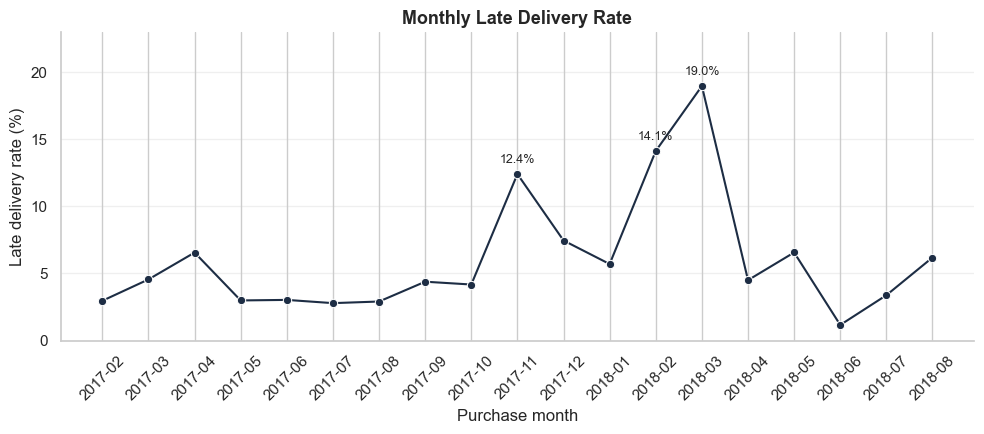

In [54]:
monthly_min_orders = 1000
monthly_delivery_plot = monthly_delivery.loc[monthly_delivery["orders"] >= monthly_min_orders].copy()

fig, ax = plt.subplots(figsize=(10, 4.5))

sns.lineplot(data=monthly_delivery_plot, x="purchase_month", y="late_rate_pct", marker="o", color=project_palette["deep_navy"], ax=ax)

peak_months = monthly_delivery_plot.sort_values("late_rate_pct", ascending=False).head(3)

for _, row in peak_months.iterrows():
    ax.text(row["purchase_month"], row["late_rate_pct"] + 0.6, f"{row['late_rate_pct']:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_title("Monthly Late Delivery Rate", fontsize=13, weight="bold")
ax.set_xlabel("Purchase month")
ax.set_ylabel("Late delivery rate (%)")
ax.set_ylim(0, monthly_delivery_plot["late_rate_pct"].max() + 4)
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

### Key takeaway

Late delivery risk varies substantially over time.

After excluding very low-volume startup months from the visualization, the clearest spikes appear in November 2017, February 2018, and especially March 2018, when the late delivery rate reached 18.96%.

This suggests that delivery risk is not only driven by geography, freight, or product profile, but also by time-period effects. Monthly trends should therefore be considered in dashboard design and future feature engineering.

### Peak month diagnostic

The monthly trend shows clear late delivery spikes in November 2017, February 2018, and March 2018.

This short diagnostic compares those peak months against the rest of the dataset to understand whether the spike is associated with broader order characteristics or with specific geographic patterns.

In [57]:
peak_months = ["2017-11", "2018-02", "2018-03"]

peak_month_check = eda_orders_full.copy()
peak_month_check["period"] = np.where(peak_month_check["purchase_month"].isin(peak_months), "Peak months", "Other months")
peak_month_check["is_cross_state"] = ~peak_month_check["customer_seller_same_state"]

peak_month_profile = (
    peak_month_check.groupby("period", as_index=False).agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        late_rate=("is_late", "mean"),
        median_delay_days=("delivery_delay_days", "median"),
        cross_state_share=("is_cross_state", "mean"),
        median_freight_value=("total_freight_value", "median"),
        median_order_value=("total_order_item_value", "median"))
)

peak_month_profile["late_rate_pct"] = peak_month_profile["late_rate"] * 100
peak_month_profile["cross_state_share_pct"] = peak_month_profile["cross_state_share"] * 100
peak_month_profile = peak_month_profile.set_index("period").loc[["Other months", "Peak months"]].reset_index()

peak_month_pair_impact = (
    peak_month_check.loc[peak_month_check["period"].eq("Peak months")]
    .assign(seller_customer_state_pair=lambda df: df["main_seller_state"] + " → " + df["customer_state"])
    .groupby("seller_customer_state_pair", as_index=False).agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        late_rate=("is_late", "mean"))
)

peak_month_pair_impact["late_rate_pct"] = peak_month_pair_impact["late_rate"] * 100
peak_month_pair_impact = peak_month_pair_impact.sort_values("late_orders", ascending=False).head(10)

display(peak_month_profile)
display(peak_month_pair_impact)

,period,orders,late_orders,late_rate,median_delay_days,cross_state_share,median_freight_value,median_order_value,late_rate_pct,cross_state_share_pct
0,Other months,75624,3376,0.04,-13.00,0.64,17.26,105.30,4.46,63.66
1,Peak months,20846,3158,0.15,-9.00,0.66,16.98,104.37,15.15,65.68


,seller_customer_state_pair,orders,late_orders,late_rate,late_rate_pct
287,SP → RJ,1862,696,0.37,37.38
294,SP → SP,6379,512,0.08,8.03
279,SP → MG,1681,244,0.15,14.52
291,SP → RS,795,139,0.17,17.48
273,SP → BA,513,125,0.24,24.37
292,SP → SC,547,122,0.22,22.30
276,SP → ES,333,96,0.29,28.83
286,SP → PR,674,87,0.13,12.91
274,SP → CE,220,84,0.38,38.18
179,PR → RJ,259,82,0.32,31.66


### Key takeaway

Late delivery spikes are highly concentrated in specific months and geographic relationships.

Peak months show a late delivery rate of 15.15%, compared with 4.46% in the rest of the dataset. This difference does not appear to be mainly explained by freight value, order value, or a much higher cross-state share.

The strongest signal comes from specific customer-seller state pairs during peak months, especially SP → RJ, which reached a 37.38% late delivery rate and generated 696 late orders.

This suggests that time-period effects and specific logistics relationships should be monitored together in the dashboard and considered during feature engineering.

## Key business insights

This EDA identified several delivery-risk patterns that are relevant from an operational and business perspective.

1. **Late delivery is a focused but meaningful problem.**  
Using the official date-level definition, 6.77% of delivered orders arrived after the estimated delivery date. Most orders arrive on time, but the late segment is large enough to represent a relevant operational and customer-experience risk.

2. **Late deliveries are not only frequent enough to matter, but also severe when they occur.**  
The median late order arrived 7 days after the estimated delivery date, and the upper tail includes delays of several weeks. This shows that late delivery is both a frequency and severity problem.

3. **Geography is one of the strongest signals.**  
Customer states show different late delivery patterns. Some states have high relative risk, while high-volume states generate the largest absolute number of late orders. RJ is especially relevant because it combines substantial volume with elevated late delivery risk.

4. **Customer-seller geography adds important logistics context.**  
Cross-state orders have a much higher late delivery rate than same-state orders. Specific customer-seller state pairs, especially SP → RJ, concentrate a large number of late orders and show high late delivery rates.

5. **Freight value is a strong economic/logistics signal.**  
Late delivery risk increases across freight value quintiles. Orders in the highest freight quintile have almost twice the late delivery rate of orders in the lowest quintile, suggesting that freight value captures relevant logistics complexity.

6. **Product profile matters, but should not be interpreted in isolation.**  
High-volume categories such as bed_bath_table and health_beauty generate the largest number of late orders. Some lower-volume categories, such as audio, home_confort, and office_furniture, show higher relative risk. Physical product characteristics such as weight and volume show weaker but still relevant patterns.

7. **Late deliveries strongly damage customer satisfaction.**  
On-time orders have an average review score of 4.29, while late orders drop to 2.27. This confirms that late delivery is not only an operational issue, but also a customer-experience problem.

8. **Time-period effects are important.**  
Late delivery risk varies significantly over time. Peak months such as November 2017, February 2018, and March 2018 show much higher late delivery rates, especially in specific customer-seller state relationships.

## Implications for feature engineering and dashboard design

The EDA suggests several variables and views that should guide the next stages of the project.

For future feature engineering, the most relevant candidate feature groups are:

- customer geography, especially customer state;
- seller geography and customer-seller state relationship;
- cross-state delivery indicator;
- customer-seller state pair;
- freight value;
- order value;
- product category;
- product weight and volume;
- purchase month or seasonal period indicators;
- payment profile variables as secondary contextual features.

The analysis also confirms several leakage-sensitive variables that must not be used as predictive features:

- actual customer delivery date;
- delivery delay fields;
- review score and review comments;
- final delivery outcome variables;
- any information only known after delivery.

For dashboard design, the most useful views should include:

- overall late delivery rate;
- late delivery rate over time;
- customer state risk and impact;
- customer-seller state pair impact;
- freight value and product profile patterns;
- review score impact as post-delivery diagnostic context.

The dashboard should separate **relative risk** from **absolute operational impact**, because a high late delivery rate in a low-volume segment does not have the same business priority as a moderate late rate in a high-volume segment.

## Final conclusions and next steps

This notebook analyzed historical delivery performance using the official date-level late delivery definition.

The analysis shows that late delivery risk is not random. It is associated with geography, customer-seller state relationships, freight value, product profile, and time-period effects. The strongest operational signals come from cross-state delivery, specific state pairs such as SP → RJ, high freight value orders, and peak delivery months.

The review score analysis confirms the business relevance of the problem: late deliveries are strongly associated with lower customer satisfaction.

The next stage should use these findings to build a leakage-safe feature engineering dataset for machine learning. The target should follow the official date-level definition, while post-delivery variables should be excluded from predictive features.

A dashboard can also be designed from these findings to monitor late delivery risk by time, geography, customer-seller relationship, freight profile, and product category.